# Event Tree Analysis (ETA) of a Cyber-Induced Valve Control Failure in an Oil Pipeline Pumping Station

## Introduction
This project presents an **Event Tree Analysis (ETA)** for a **cyber-induced valve control failure** in an oil pipeline pumping station.  
The case study begins with an initiating event:

**“Malicious or faulty control signal disrupts pipeline valve operation.”**

From this initiating event, the code models how the system evolves depending on whether different protective barriers succeed or fail.

## Case Study Overview
The pipeline pumping station is protected by multiple layers of defense:

1. **Intrusion monitoring system** detects abnormal commands  
2. **Access control system** blocks unauthorized valve actions  
3. **Pressure relief system** protects the pipeline from dangerous pressure build-up  
4. **Operator response** isolates the affected pipeline section if automatic barriers fail  

## What the Code Does
This ETA code performs the following tasks:

- Defines the **barriers** used in the event tree
- Assigns **success and failure probabilities**
- Generates **all possible event paths**
- Calculates the **probability of each path**
- Classifies outcomes into:
  - **SAFE**
  - **PARTIAL FAILURE**
  - **CATASTROPHIC FAILURE**
- Builds summary tables
- Draws the **event tree diagram**
- Displays final ETA results for analysis

## Objective
The purpose of this code is to show how a single initiating event can propagate through multiple success/failure branches and lead to different final consequences. This helps in understanding **risk propagation**, **barrier effectiveness**, and **system vulnerability** in a cybersecurity-related industrial scenario.

## Block 1: Import Required Libraries

In this block, we import all the Python libraries required for the Event Tree Analysis.

These libraries are used for:

- creating structured data classes
- handling lists, dictionaries, and optional values
- creating tables using pandas
- plotting custom icons using matplotlib
- drawing the event tree diagram using Graphviz
- displaying the generated image inside the notebook

In [3]:
# Enables postponed evaluation of type hints for cleaner class annotations
from __future__ import annotations

# Used to create simple data container classes automatically
from dataclasses import dataclass

# Used for type hinting such as Dict, List, Optional, Tuple, and Callable
from typing import Dict, List, Optional, Tuple, Callable

# Used for file and folder handling
import os

# Used to create temporary folders for storing generated icons
import tempfile

# Used to automatically initialize dictionary values
from collections import defaultdict

# Used to create tabular outputs
import pandas as pd

# Used for plotting shapes and saving icon images
import matplotlib.pyplot as plt

# Used to draw circular, rectangular, and rounded box icons
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch

# Used to build and render the event tree diagram
from graphviz import Digraph

# Used to display the generated event tree image in notebook output
from IPython.display import Image, display

## Block 2: Define Data Classes

This block defines the basic data structures used in the ETA model.

### 1. `ETABarrier`
This class stores information about each barrier:
- barrier name
- success probability
- barrier type

It also validates that:
- probability is between 0 and 1
- barrier type is valid

### 2. `ETAPathResult`
This class stores the final result of each generated path:
- path number
- success/failure decisions
- probability of that path
- outcome name
- outcome category

In [4]:

# Creates a lightweight class to store barrier-related data
@dataclass
class ETABarrier:
    # Name of the barrier
    name: str

    # Probability that the barrier succeeds
    success_probability: float

    # Type of barrier: SECURITY, SAFETY, or HUMAN
    barrier_type: str = "SAFETY"

    # Validates whether the barrier has proper values
    def validate(self) -> None:
        # Check if probability is within valid bounds
        if not (0.0 <= self.success_probability <= 1.0):
            raise ValueError(
                f"Barrier '{self.name}' must have success probability between 0 and 1."
            )

        # Allowed barrier categories
        valid_types = {"SECURITY", "SAFETY", "HUMAN"}

        # Check whether barrier type is valid
        if self.barrier_type not in valid_types:
            raise ValueError(
                f"Barrier '{self.name}' has invalid type '{self.barrier_type}'. "
                f"Choose from {valid_types}."
            )


# Creates a class to store the result of one complete ETA path
@dataclass
class ETAPathResult:
    # Unique ID for the path
    path_id: int

    # List of success/failure decisions for each barrier
    decisions: List[bool]

    # Probability of that exact path
    path_probability: float

    # Descriptive outcome name
    outcome_name: str

    # Category of outcome: SAFE / PARTIAL FAILURE / CATASTROPHIC FAILURE
    outcome_category: str

## Block 3: Helper Functions

This block contains small reusable functions that support the main ETA model.

These functions are used for:
- computing failure probability from success probability
- formatting probabilities for display
- converting True/False branch values to Success/Failure text
- wrapping long text labels for the event tree diagram
- classifying outcomes into categories
- assigning colors and icons based on outcome type

In [13]:


# Returns failure probability from a given success probability
def failure_probability(success_probability: float) -> float:
    # Failure probability = 1 - success probability
    return 1.0 - success_probability


# Formats probabilities into readable display text
def format_prob(p: float, decimals: int = 4) -> str:
    # Example output: P = 0.1234
    return f"P = {round(p, decimals):g}"


# Converts Boolean decision into readable branch text
def branch_text(decision: bool) -> str:
    # True means Success, False means Failure
    return "Success" if decision else "Failure"


# Wraps long labels into multiple lines for better diagram readability
def wrap_text(text: str, max_len: int = 26, max_lines: int = 5) -> str:
    # Split the text into individual words
    words = text.split()

    # Store wrapped lines here
    lines = []

    # Current line under construction
    current = ""

    # Loop through each word in the text
    for word in words:
        # Try adding the next word to the current line
        candidate = f"{current} {word}".strip()

        # If it fits, keep building the same line
        if len(candidate) <= max_len:
            current = candidate
        else:
            # Otherwise, save the current line first
            if current:
                lines.append(current)
            # Start a new line with the current word
            current = word

    # Add the last unfinished line
    if current:
        lines.append(current)

    # Limit the number of displayed lines
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:max(0, max_len - 3)] + "..."

    # Join lines with newline character
    return "\n".join(lines)


# Classifies an outcome description into an ETA category
def classify_outcome(outcome_name: str) -> str:
    # Convert outcome name to lowercase for easier comparison
    lower_name = outcome_name.lower()

    # If safe-related keywords appear, classify as SAFE
    if any(k in lower_name for k in ["safe", "stable", "maintained", "isolated", "blocked", "controlled"]):
        return "SAFE"

    # If partial-loss-related keywords appear, classify as PARTIAL FAILURE
    if any(k in lower_name for k in ["partial", "degraded", "recovery", "contained", "limited"]):
        return "PARTIAL FAILURE"

    # Otherwise, classify as catastrophic
    return "CATASTROPHIC FAILURE"


# Returns fill color for different outcome categories
def outcome_fillcolor(category: str) -> str:
    # Greenish for safe
    if category == "SAFE":
        return "#D9EAD3"

    # Yellowish for partial failure
    if category == "PARTIAL FAILURE":
        return "#FFF2CC"

    # Redish for catastrophic failure
    return "#F4CCCC"


# Returns icon key corresponding to outcome category
def outcome_icon_key(category: str) -> str:
    # Safe icon
    if category == "SAFE":
        return "SAFE"

    # Partial outcome icon
    if category == "PARTIAL FAILURE":
        return "PARTIAL"

    # Hazard icon
    return "HAZARD"

## Block 4: Create Icons for the Event Tree

This block creates custom icons for:
- initiating event
- security barrier
- safety barrier
- human barrier
- safe outcome
- partial failure outcome
- hazardous outcome

These icons are saved temporarily and later used inside the Graphviz event tree diagram to make the output more visual and professional.

In [6]:

# Creates and saves all icons needed for the ETA diagram
def create_eta_icons(output_dir: str) -> Dict[str, str]:
    # Create the output directory if it does not exist
    os.makedirs(output_dir, exist_ok=True)

    # Dictionary storing file paths for all icon images
    paths = {
        "INIT": os.path.join(output_dir, "init_event.png"),
        "SECURITY": os.path.join(output_dir, "security_barrier.png"),
        "SAFETY": os.path.join(output_dir, "safety_barrier.png"),
        "HUMAN": os.path.join(output_dir, "human_barrier.png"),
        "SAFE": os.path.join(output_dir, "safe_outcome.png"),
        "PARTIAL": os.path.join(output_dir, "partial_outcome.png"),
        "HAZARD": os.path.join(output_dir, "hazard_outcome.png"),
    }

    # INITIATING EVENT ICON
    fig, ax = plt.subplots(figsize=(2.3, 1.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    init_box = FancyBboxPatch(
        (0.08, 0.20), 0.84, 0.60,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor="#F4CCCC",
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(init_box)
    ax.text(0.5, 0.5, "INIT", ha="center", va="center", fontsize=11, weight="bold")
    plt.savefig(paths["INIT"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # SECURITY BARRIER ICON
    fig, ax = plt.subplots(figsize=(1.4, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Circle((0.5, 0.5), 0.34, facecolor="#F4CCCC", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "SEC", ha="center", va="center", fontsize=8.5, weight="bold")
    plt.savefig(paths["SECURITY"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # SAFETY BARRIER ICON
    fig, ax = plt.subplots(figsize=(1.4, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Circle((0.5, 0.5), 0.34, facecolor="#D9EAD3", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "SAFE", ha="center", va="center", fontsize=7.5, weight="bold")
    plt.savefig(paths["SAFETY"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # HUMAN BARRIER ICON
    fig, ax = plt.subplots(figsize=(1.4, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Circle((0.5, 0.5), 0.34, facecolor="#CFE2F3", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "H", ha="center", va="center", fontsize=11, weight="bold")
    plt.savefig(paths["HUMAN"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # SAFE OUTCOME ICON
    fig, ax = plt.subplots(figsize=(2.0, 1.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Rectangle((0.10, 0.18), 0.80, 0.64, facecolor="#D9EAD3", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "SAFE", ha="center", va="center", fontsize=11, weight="bold")
    plt.savefig(paths["SAFE"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # PARTIAL FAILURE ICON
    fig, ax = plt.subplots(figsize=(2.1, 1.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Rectangle((0.08, 0.18), 0.84, 0.64, facecolor="#FFF2CC", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "PARTIAL", ha="center", va="center", fontsize=10, weight="bold")
    plt.savefig(paths["PARTIAL"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # HAZARD OUTCOME ICON
    fig, ax = plt.subplots(figsize=(2.1, 1.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    obj = Rectangle((0.08, 0.18), 0.84, 0.64, facecolor="#EA9999", edgecolor="black", linewidth=1.2)
    ax.add_patch(obj)
    ax.text(0.5, 0.5, "HAZARD", ha="center", va="center", fontsize=10, weight="bold")
    plt.savefig(paths["HAZARD"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Return the dictionary of saved icon paths
    return paths

## Block 5: Build the Main Event Tree Class

This is the core block of the ETA project.

The `EventTree` class is responsible for:
- validating the initiating event and barriers
- generating all success/failure paths
- determining the final outcome of each path
- creating barrier and path summary tables
- grouping final results into categories

This is the computational heart of the Event Tree Analysis.

In [7]:

# Main class for building and analyzing the event tree
class EventTree:
    # Constructor method for initializing the event tree
    def __init__(
        self,
        initiating_event: str,
        barriers: List[ETABarrier],
        title: str = "Event Tree Analysis",
        outcome_logic: Optional[Callable[[List[bool]], str]] = None
    ) -> None:
        # Store the initiating event description
        self.initiating_event = initiating_event

        # Store the list of barriers
        self.barriers = barriers

        # Store analysis title
        self.title = title

        # Optional custom logic to determine outcomes
        self.outcome_logic = outcome_logic

        # Validate the tree immediately after creation
        self._validate_tree()

    # Internal method to validate tree inputs
    def _validate_tree(self) -> None:
        # Initiating event should not be empty
        if not self.initiating_event.strip():
            raise ValueError("Initiating event must not be empty.")

        # There must be at least one barrier
        if not self.barriers:
            raise ValueError("At least one barrier is required in the event tree.")

        # Validate each barrier
        for barrier in self.barriers:
            barrier.validate()

    # Determines the outcome for a given combination of barrier decisions
    def _determine_outcome(self, decisions: List[bool]) -> Tuple[str, str]:
        # If user has provided custom outcome logic, use it
        if self.outcome_logic is not None:
            outcome_name = self.outcome_logic(decisions)
            outcome_category = classify_outcome(outcome_name)
            return outcome_name, outcome_category

        # Default logic if no custom logic is supplied
        if all(decisions):
            return "All barriers succeed - Safe state maintained", "SAFE"

        if decisions[-1]:
            return "Late recovery after earlier failures", "PARTIAL FAILURE"

        return "Barrier failure sequence leads to catastrophic state", "CATASTROPHIC FAILURE"

    # Generates all possible paths in the event tree
    def generate_paths(self) -> List[ETAPathResult]:
        # List to store all final path results
        results: List[ETAPathResult] = []

        # Counter to assign path IDs
        path_counter = 1

        # Recursive function to build each path
        def recurse(index: int, current_decisions: List[bool], current_probability: float) -> None:
            nonlocal path_counter

            # If all barriers have been processed, finalize the path
            if index == len(self.barriers):
                outcome_name, outcome_category = self._determine_outcome(current_decisions)
                results.append(
                    ETAPathResult(
                        path_id=path_counter,
                        decisions=current_decisions.copy(),
                        path_probability=current_probability,
                        outcome_name=outcome_name,
                        outcome_category=outcome_category
                    )
                )
                path_counter += 1
                return

            # Get current barrier
            barrier = self.barriers[index]

            # Branch 1: barrier succeeds
            current_decisions.append(True)
            recurse(index + 1, current_decisions, current_probability * barrier.success_probability)
            current_decisions.pop()

            # Branch 2: barrier fails
            current_decisions.append(False)
            recurse(index + 1, current_decisions, current_probability * failure_probability(barrier.success_probability))
            current_decisions.pop()

        # Start recursive path generation
        recurse(0, [], 1.0)

        # Return all computed paths
        return results

    # Creates a table showing each barrier and its probabilities
    def barrier_table(self) -> pd.DataFrame:
        # List to hold barrier rows
        rows = []

        # Loop through each barrier
        for i, barrier in enumerate(self.barriers, start=1):
            rows.append({
                "ID": i,
                "Barrier": barrier.name,
                "Barrier Type": barrier.barrier_type,
                "Success Probability": format_prob(barrier.success_probability),
                "Failure Probability": format_prob(failure_probability(barrier.success_probability))
            })

        # Convert rows to DataFrame
        return pd.DataFrame(rows)

    # Creates a table for all paths and their outcomes
    def path_table(self) -> pd.DataFrame:
        # List to hold path rows
        rows = []

        # Loop through every generated path
        for result in self.generate_paths():
            decision_text = " | ".join(
                f"{self.barriers[i].name}: {branch_text(result.decisions[i])}"
                for i in range(len(self.barriers))
            )
            rows.append({
                "Path ID": result.path_id,
                "Branch Decisions": decision_text,
                "Path Probability": format_prob(result.path_probability),
                "Outcome": result.outcome_name,
                "Outcome Category": result.outcome_category
            })

        # Convert rows to DataFrame
        return pd.DataFrame(rows)

    # Creates a summary table by grouped outcomes
    def outcome_summary_table(self) -> pd.DataFrame:
        # Dictionary to sum probabilities for same outcomes
        grouped = defaultdict(float)

        # Aggregate probabilities by outcome name and category
        for result in self.generate_paths():
            grouped[(result.outcome_name, result.outcome_category)] += result.path_probability

        # Prepare rows for output
        rows = []

        # Sort grouped outcomes by descending probability
        for i, ((outcome_name, category), total_prob) in enumerate(
            sorted(grouped.items(), key=lambda x: x[1], reverse=True),
            start=1
        ):
            rows.append({
                "ID": i,
                "Outcome": outcome_name,
                "Outcome Category": category,
                "Total Probability": format_prob(total_prob)
            })

        # Convert rows to DataFrame
        return pd.DataFrame(rows)

    # Creates a comparison table for major outcome categories
    def category_comparison_table(self) -> pd.DataFrame:
        # Dictionary to store category totals
        totals = defaultdict(float)

        # Sum probabilities for each broad category
        for result in self.generate_paths():
            totals[result.outcome_category] += result.path_probability

        # Fixed order of display categories
        categories = ["SAFE", "PARTIAL FAILURE", "CATASTROPHIC FAILURE"]

        # Create rows
        rows = []
        for i, category in enumerate(categories, start=1):
            rows.append({
                "ID": i,
                "Category": category,
                "Total Probability": format_prob(totals.get(category, 0.0))
            })

        # Convert to DataFrame
        return pd.DataFrame(rows)

## Block 6: Extend the Event Tree Class for Visualization and Dashboard Output

This block adds two major capabilities:

### 1. `visualize_event_tree()`
This method:
- creates the full event tree diagram
- places icons for each barrier and outcome
- labels branches with success/failure probabilities
- saves and displays the generated ETA diagram

### 2. `run_dashboard()`
This method:
- runs the full analysis
- calculates total probabilities for safe, partial, and catastrophic outcomes
- displays the event tree
- returns all result tables

In [8]:
# Extends the EventTree class by adding visualization and dashboard features
class EventTree(EventTree):
    # Draws and saves the event tree diagram
    def visualize_event_tree(self, save_path: Optional[str] = None) -> str:
        # Use custom save path if given, otherwise default file name
        output_name = save_path if save_path else "eta_event_tree"

        # Create temporary directory for storing icons
        temp_dir = tempfile.mkdtemp(prefix="eta_icons_")

        # Generate all required icon files
        icon_paths = create_eta_icons(temp_dir)

        # Create a Graphviz directed graph
        dot = Digraph("ETA", format="png")

        # Set diagram layout from left to right
        dot.attr(rankdir="LR", splines="polyline", nodesep="0.85", ranksep="1.1")
        dot.attr(fontname="Helvetica")
        dot.attr("node", fontname="Helvetica")
        dot.attr("edge", fontname="Helvetica", fontsize="9")

        # IDs for initiating event label and symbol
        init_event_id = "init_event"
        init_symbol_id = "init_symbol"

        # Add initiating event text box
        dot.node(
            init_event_id,
            label=wrap_text(self.initiating_event, max_len=28, max_lines=4),
            shape="box",
            style="rounded,filled",
            fillcolor="white",
            color="black",
            width="2.9",
            height="0.95",
            penwidth="1.2"
        )

        # Add initiating event icon
        dot.node(
            init_symbol_id,
            label="",
            shape="none",
            image=icon_paths["INIT"],
            imagescale="true",
            width="1.1",
            height="0.6",
            fixedsize="true"
        )

        # Connect initiating event text to its icon
        dot.edge(init_event_id, init_symbol_id, arrowhead="none", penwidth="1.1")

        # Start traversal from initiating symbol
        current_nodes = [init_symbol_id]

        # Loop over each barrier level
        for level, barrier in enumerate(self.barriers, start=1):
            # Store next layer of nodes here
            next_nodes = []

            # For each parent node, create a barrier block
            for parent_idx, parent_node in enumerate(current_nodes):
                barrier_event_id = f"b{level}_{parent_idx}_event"
                barrier_symbol_id = f"b{level}_{parent_idx}_symbol"

                # Add barrier description box
                dot.node(
                    barrier_event_id,
                    label=wrap_text(barrier.name, max_len=26, max_lines=4),
                    shape="box",
                    style="rounded,filled",
                    fillcolor="white",
                    color="black",
                    width="2.6",
                    height="0.85",
                    penwidth="1.1"
                )

                # Add barrier icon based on barrier type
                dot.node(
                    barrier_symbol_id,
                    label="",
                    shape="none",
                    image=icon_paths[barrier.barrier_type],
                    imagescale="true",
                    width="0.78",
                    height="0.56",
                    fixedsize="true"
                )

                # Connect parent to barrier description and icon
                dot.edge(parent_node, barrier_event_id, arrowhead="none", penwidth="1.0")
                dot.edge(barrier_event_id, barrier_symbol_id, arrowhead="none", penwidth="1.0")

                # Create success and failure branch stubs
                success_stub = f"b{level}_{parent_idx}_S"
                failure_stub = f"b{level}_{parent_idx}_F"

                # Add success and failure labels
                dot.node(success_stub, label="Success", shape="plaintext", fontcolor="darkgreen", fontsize="10")
                dot.node(failure_stub, label="Failure", shape="plaintext", fontcolor="red", fontsize="10")

                # Format success and failure probabilities
                s_prob = format_prob(barrier.success_probability)
                f_prob = format_prob(failure_probability(barrier.success_probability))

                # Connect success branch
                dot.edge(
                    barrier_symbol_id,
                    success_stub,
                    label=f"S\n{s_prob}",
                    color="darkgreen",
                    penwidth="1.1"
                )

                # Connect failure branch
                dot.edge(
                    barrier_symbol_id,
                    failure_stub,
                    label=f"F\n{f_prob}",
                    color="red",
                    penwidth="1.1"
                )

                # Add both next-level nodes
                next_nodes.extend([success_stub, failure_stub])

            # Move to next level
            current_nodes = next_nodes

        # Generate all path results for final outcomes
        all_paths = self.generate_paths()

        # Add terminal outcome nodes
        for idx, result in enumerate(all_paths):
            # Parent stub node corresponding to this path
            parent_stub = current_nodes[idx]

            # Unique outcome node ID
            outcome_id = f"outcome_{idx}"

            # Outcome node label
            label_text = (
                f"Path {result.path_id}\n"
                f"{wrap_text(result.outcome_name, max_len=28, max_lines=5)}\n"
                f"{format_prob(result.path_probability)}"
            )

            # Add outcome node with icon and fill color
            dot.node(
                outcome_id,
                label=label_text,
                shape="box",
                style="rounded,filled",
                fillcolor=outcome_fillcolor(result.outcome_category),
                color="black",
                image=icon_paths[outcome_icon_key(result.outcome_category)],
                labelloc="b",
                imagescale="true",
                width="2.9",
                height="1.2",
                fontsize="8.5",
                penwidth="1.2"
            )

            # Edge color based on category
            edge_color = (
                "darkgreen" if result.outcome_category == "SAFE"
                else "goldenrod" if result.outcome_category == "PARTIAL FAILURE"
                else "red"
            )

            # Connect final stub to outcome
            dot.edge(
                parent_stub,
                outcome_id,
                arrowhead="none",
                color=edge_color,
                penwidth="1.2"
            )

        # Render and save PNG image
        png_path = dot.render(output_name, cleanup=True)

        # Display image if saved successfully
        if os.path.exists(png_path):
            display(Image(filename=png_path))
        else:
            print("Could not find generated ETA image. Please check Graphviz installation.")

        # Print file save location
        print(f"ETA diagram saved as: {png_path}")

        # Return saved image path
        return png_path

    # Runs the complete ETA dashboard
    def run_dashboard(self, image_path: Optional[str] = None) -> Dict[str, pd.DataFrame]:
        # Generate all paths
        path_results = self.generate_paths()

        # Compute total safe probability
        safe_total = sum(p.path_probability for p in path_results if p.outcome_category == "SAFE")

        # Compute total partial failure probability
        partial_total = sum(p.path_probability for p in path_results if p.outcome_category == "PARTIAL FAILURE")

        # Compute total catastrophic failure probability
        catastrophic_total = sum(p.path_probability for p in path_results if p.outcome_category == "CATASTROPHIC FAILURE")

        # Print dashboard header
        print("=" * 110)
        print(self.title.upper())
        print("=" * 110)
        print()
        print(f"Initiating Event: {self.initiating_event}")
        print(f"Total Number of Paths: {len(path_results)}")
        print(f"Safe Outcome Probability: {format_prob(safe_total)}")
        print(f"Partial Failure Probability: {format_prob(partial_total)}")
        print(f"Catastrophic Failure Probability: {format_prob(catastrophic_total)}")
        print()

        # Draw event tree diagram
        self.visualize_event_tree(save_path=image_path)

        # Generate all result tables
        barrier_df = self.barrier_table()
        path_df = self.path_table()
        outcome_df = self.outcome_summary_table()
        category_df = self.category_comparison_table()

        # Return all outputs in dictionary form
        return {
            "barrier_probability_table": barrier_df,
            "path_outcome_table": path_df,
            "final_outcome_summary": outcome_df,
            "category_comparison": category_df,
        }

## Block 7: Define Case-Specific Outcome Logic

This block defines how the final outcome is interpreted based on the success or failure of barriers.

For this pipeline case study:
- if abnormal command is detected early, the system remains safe
- if detection fails but access control works, the unsafe action is blocked
- if both fail but pressure relief works, the situation is controlled
- if automatic systems fail but operator responds correctly, only partial recovery occurs
- if all barriers fail, the incident escalates to overpressure and pipeline leak

In [12]:


# Defines outcome logic for the oil pipeline case study
def pipeline_outcome_logic(decisions: List[bool]) -> str:
    # Barrier 1: intrusion monitoring system
    detection_works = decisions[0]

    # Barrier 2: access control system
    access_control_works = decisions[1]

    # Barrier 3: pressure relief system
    relief_system_works = decisions[2]

    # Barrier 4: operator response
    operator_works = decisions[3]

    # If abnormal command is detected immediately, safe state is maintained
    if detection_works:
        return "Abnormal command detected early - Safe operation maintained"

    # If detection fails but access control blocks valve action, safe state is maintained
    if not detection_works and access_control_works:
        return "Unauthorized valve action blocked - Safe state maintained"

    # If both security layers fail but relief system works, pressure remains controlled
    if not detection_works and not access_control_works and relief_system_works:
        return "Pressure relief controls pipeline condition - Controlled safe state"

    # If all automated barriers fail but operator acts successfully, partial recovery occurs
    if (
        not detection_works
        and not access_control_works
        and not relief_system_works
        and operator_works
    ):
        return "Operator isolates affected pipeline section - Partial recovery"

    # If every barrier fails, the incident becomes catastrophic
    if (
        not detection_works
        and not access_control_works
        and not relief_system_works
        and not operator_works
    ):
        return "Valve malfunction escalates to overpressure and pipeline leak"

    # General fallback outcome
    return "Limited pressure disturbance"

## Block 8: Build the Pipeline ETA Case Study

This block creates the specific event tree for the oil pipeline pumping station.

It defines:
- the initiating event
- all four barriers
- barrier probabilities
- barrier types
- the custom outcome logic for this case

In [10]:
# BUILD CASE STUDY

# Creates and returns the EventTree object for the pipeline case study
def build_pipeline_eta_case() -> EventTree:
    # Define all barriers used in the event tree
    barriers = [
        ETABarrier("Intrusion monitoring system detects abnormal command", 0.86, "SECURITY"),
        ETABarrier("Access control blocks unauthorized valve action", 0.90, "SECURITY"),
        ETABarrier("Pressure relief system operates correctly", 0.92, "SAFETY"),
        ETABarrier("Operator response isolates the affected section", 0.83, "HUMAN"),
    ]

    # Return the fully built event tree
    return EventTree(
        initiating_event="Malicious or faulty control signal disrupts pipeline valve operation",
        barriers=barriers,
        title="Cyber-Induced Valve Control Failure in Oil Pipeline Pumping Station - Event Tree Analysis",
        outcome_logic=pipeline_outcome_logic
    )

## Block 9: Run the Event Tree Analysis

This final block runs the complete ETA model.

It:
- builds the case study
- executes the dashboard
- generates the event tree diagram
- produces all result tables:
  - barrier probability table
  - path outcome table
  - final outcome summary
  - category comparison table

CYBER-INDUCED VALVE CONTROL FAILURE IN OIL PIPELINE PUMPING STATION - EVENT TREE ANALYSIS

Initiating Event: Malicious or faulty control signal disrupts pipeline valve operation
Total Number of Paths: 16
Safe Outcome Probability: P = 0.9989
Partial Failure Probability: P = 0.0009
Catastrophic Failure Probability: P = 0.0002



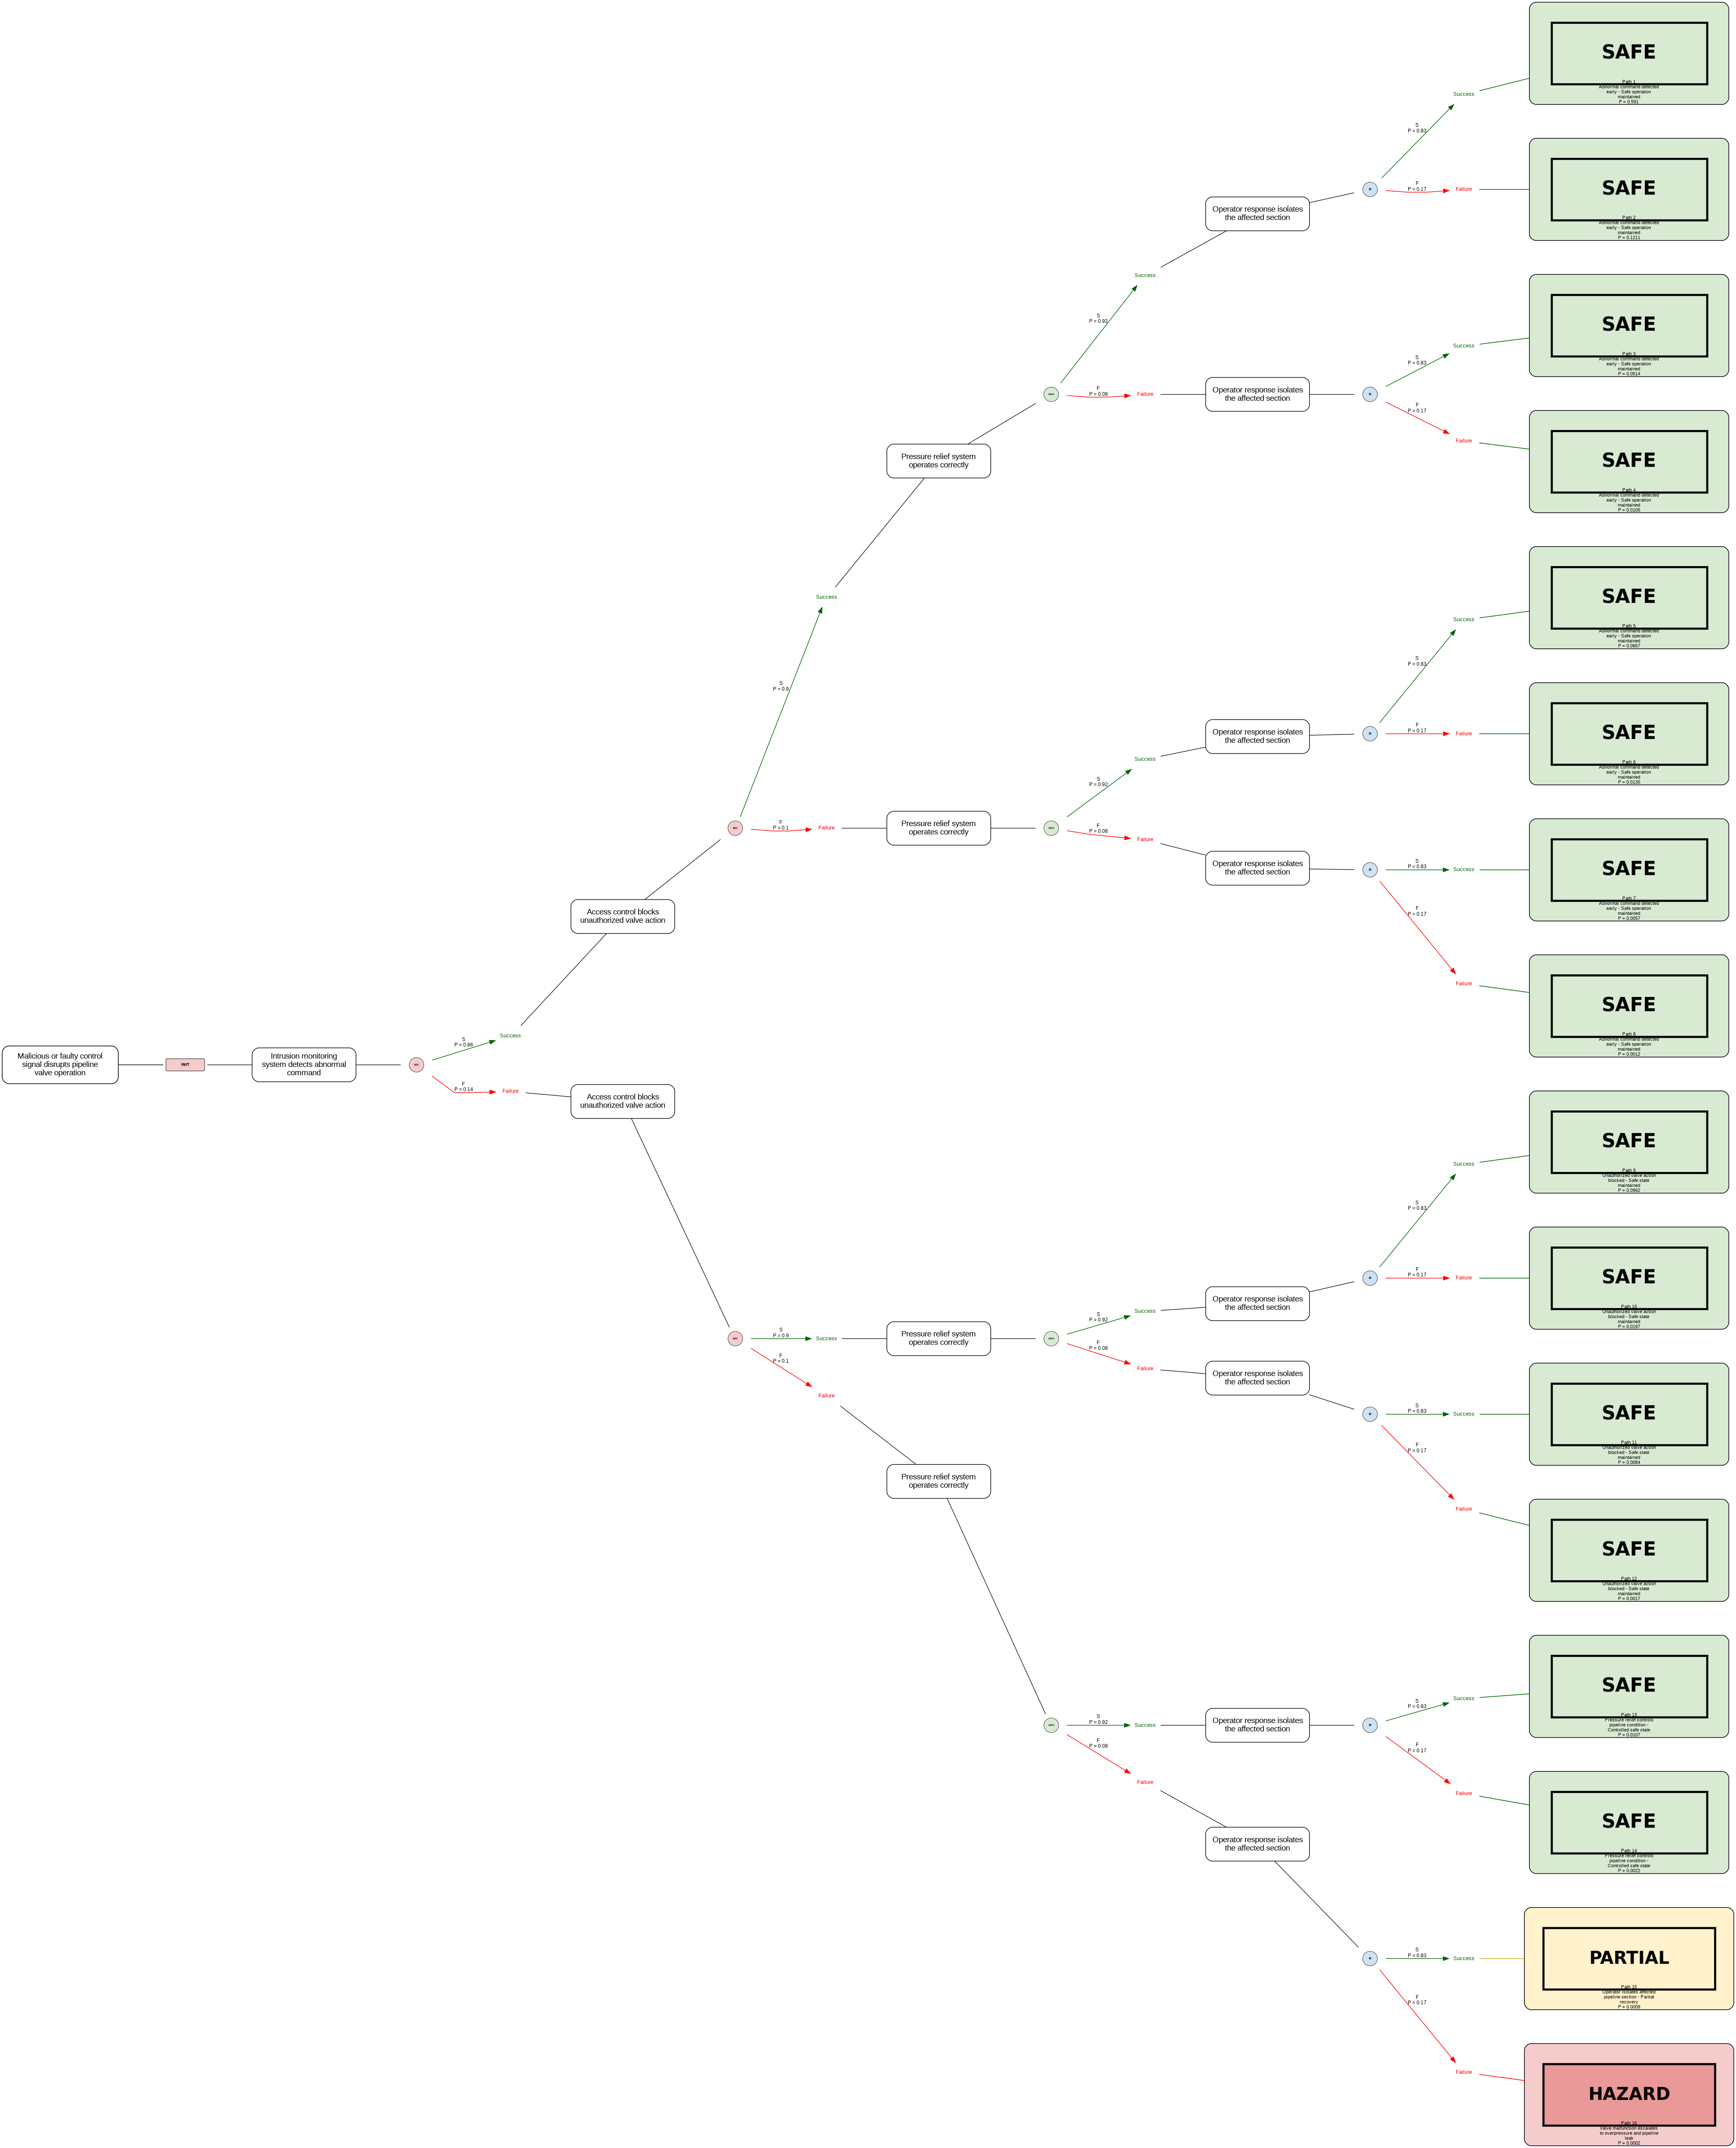

ETA diagram saved as: pipeline_eta_medium.png


,ID,Category,Total Probability
0,1,SAFE,P = 0.9989
1,2,PARTIAL FAILURE,P = 0.0009
2,3,CATASTROPHIC FAILURE,P = 0.0002


In [11]:
# Build the pipeline ETA case study
pipeline_eta = build_pipeline_eta_case()

# Run the full ETA dashboard and save the image
eta_results = pipeline_eta.run_dashboard(image_path="pipeline_eta_medium")

# Display barrier probability table
eta_results["barrier_probability_table"]

# Display path outcome table
eta_results["path_outcome_table"]

# Display final outcome summary table
eta_results["final_outcome_summary"]

# Display category comparison table
eta_results["category_comparison"]

## Conclusion

This Event Tree Analysis demonstrates how a cyber-induced valve control disruption in an oil pipeline pumping station can evolve into different outcomes depending on the success or failure of system barriers.

The analysis shows that:
- strong early detection and access control significantly improve safety
- pressure relief systems reduce escalation risk
- operator intervention provides an important final recovery layer
- simultaneous failure of all barriers can lead to a catastrophic pipeline leak

Thus, the ETA model helps in understanding the effectiveness of layered protection and supports better safety and cybersecurity risk assessment in industrial systems.